# Notebook 13: Advantage Functions & Generalized Advantage Estimation

**Series:** Reinforcement Learning Basics (13/20)

---

## 1. The Advantage Function

$$A^\pi(s, a) = Q^\pi(s, a) - V^\pi(s)$$

**Meaning:** How much **better** is action $a$ compared to the **average** action in state $s$?

**Properties:**
- $\sum_a \pi(a|s) A^\pi(s,a) = 0$ (zero mean under policy)
- $A^\pi(s,a) > 0$: action $a$ is better than average
- $A^\pi(s,a) < 0$: action $a$ is worse than average

## 2. TD Error as Advantage Estimate

$$\delta_t = R_{t+1} + \gamma V(S_{t+1}) - V(S_t)$$

$\mathbb{E}[\delta_t | S_t, A_t] = Q^\pi(S_t, A_t) - V^\pi(S_t) = A^\pi(S_t, A_t)$

So $\delta_t$ is an **unbiased** estimate of the advantage!

## 3. Generalized Advantage Estimation (GAE)

$$\hat{A}_t^{GAE(\gamma, \lambda)} = \sum_{l=0}^{\infty} (\gamma\lambda)^l \delta_{t+l}$$

**Special cases:**
- $\lambda = 0$: $\hat{A}_t = \delta_t$ (TD, low variance, high bias)
- $\lambda = 1$: $\hat{A}_t = G_t - V(S_t)$ (MC, high variance, low bias)

### Efficient Backward Computation

$$\hat{A}_T = \delta_T$$
$$\hat{A}_t = \delta_t + \gamma\lambda \, \hat{A}_{t+1}$$

This makes GAE $O(T)$ — just one backward pass!

## 4. Why GAE Matters

GAE is used in **PPO**, **TRPO**, and most modern policy gradient methods. It provides a principled way to trade off bias and variance via $\lambda$.

<>:38: SyntaxWarning: invalid escape sequence '\h'
<>:38: SyntaxWarning: invalid escape sequence '\h'
C:\Users\Milan Amrut Joshi\AppData\Local\Temp\ipykernel_57576\2795630022.py:38: SyntaxWarning: invalid escape sequence '\h'
  axes[0].set_ylabel('Advantage $\hat{A}_t^{GAE}$')


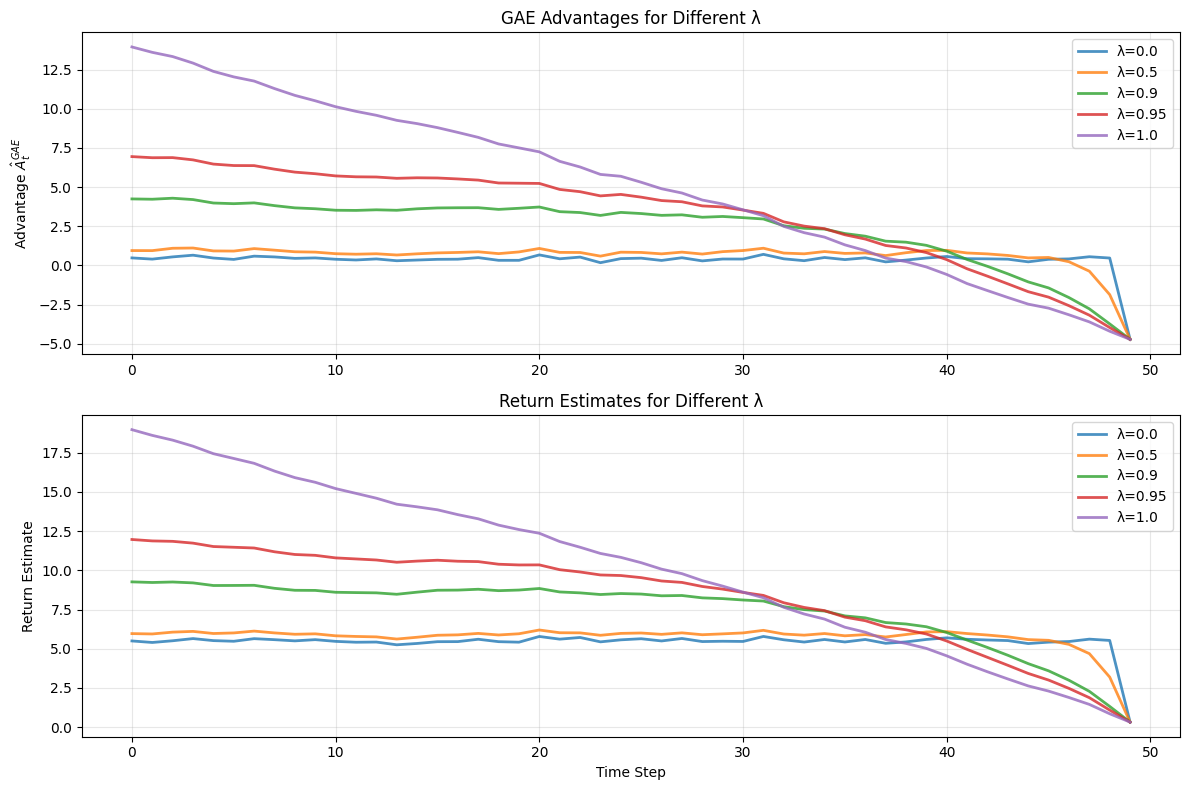

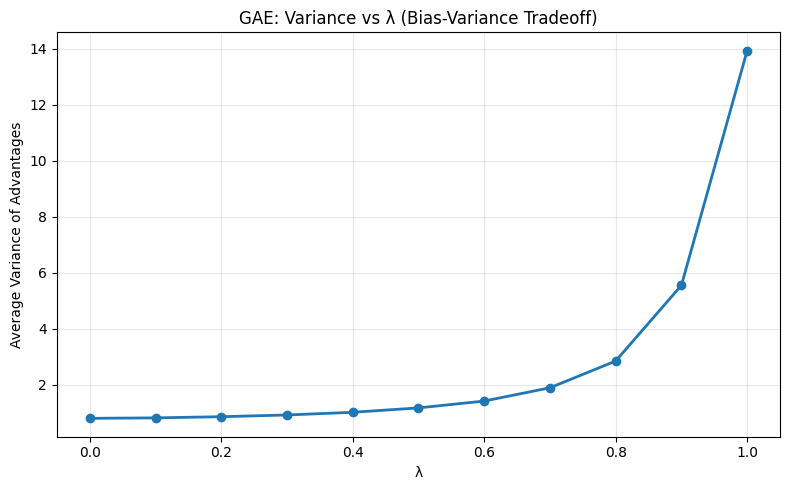

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# GAE Computation Demo
# ============================================
def compute_gae(rewards, values, gamma=0.99, lam=0.95):
    """Compute GAE advantages using backward recursion."""
    T = len(rewards)
    advantages = np.zeros(T)
    last_gae = 0

    for t in reversed(range(T)):
        if t == T - 1:
            next_value = 0  # terminal
        else:
            next_value = values[t + 1]
        delta = rewards[t] + gamma * next_value - values[t]
        advantages[t] = last_gae = delta + gamma * lam * last_gae

    returns = advantages + values
    return advantages, returns

# Simulate an episode
np.random.seed(42)
T = 50
rewards = np.random.randn(T) * 0.1 + 0.5  # noisy positive rewards
values = np.cumsum(np.random.randn(T) * 0.05) + 5  # approximate value function

# Compare different lambda values
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

for lam in [0.0, 0.5, 0.9, 0.95, 1.0]:
    adv, ret = compute_gae(rewards, values, gamma=0.99, lam=lam)
    axes[0].plot(adv, label=f'λ={lam}', alpha=0.8, linewidth=2)
    axes[1].plot(ret, label=f'λ={lam}', alpha=0.8, linewidth=2)

axes[0].set_ylabel('Advantage $\hat{A}_t^{GAE}$')
axes[0].set_title('GAE Advantages for Different λ')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Time Step')
axes[1].set_ylabel('Return Estimate')
axes[1].set_title('Return Estimates for Different λ')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Variance comparison
n_episodes = 500
var_by_lambda = {}
for lam in np.arange(0, 1.05, 0.1):
    advs = []
    for _ in range(n_episodes):
        r = np.random.randn(30) * 0.1 + 0.5
        v = np.cumsum(np.random.randn(30) * 0.05) + 5
        a, _ = compute_gae(r, v, lam=lam)
        advs.append(np.var(a))
    var_by_lambda[round(lam, 1)] = np.mean(advs)

plt.figure(figsize=(8, 5))
plt.plot(list(var_by_lambda.keys()), list(var_by_lambda.values()), 'o-', linewidth=2)
plt.xlabel('λ')
plt.ylabel('Average Variance of Advantages')
plt.title('GAE: Variance vs λ (Bias-Variance Tradeoff)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

| Concept | Formula |
|---------|---------|
| **Advantage** | $A^\pi(s,a) = Q^\pi(s,a) - V^\pi(s)$ |
| **GAE** | $\hat{A}_t = \sum_{l=0}^\infty (\gamma\lambda)^l \delta_{t+l}$ |
| **Backward recursion** | $\hat{A}_t = \delta_t + \gamma\lambda \hat{A}_{t+1}$ |
| **λ=0** | TD advantage (low var, high bias) |
| **λ=1** | MC advantage (high var, low bias) |

**Next:** Notebook 14 — PPO